In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [3]:
class BrokenNet(nn.Module):
    def __init__(self, depth=8, width=32, in_features=20):
        super().__init__()
        layers = []
        n_in = in_features
        for _ in range(depth):
            layers.append(nn.Linear(n_in, width))
            n_in = width
        self.hidden = nn.ModuleList(layers)
        self.out = nn.Linear(width, 1)

        for layer in self.hidden:
            nn.init.normal_(layer.weight, mean=0.0, std=0.3)
            nn.init.constant_(layer.bias, -2.0)

    def forward(self, x):
        for layer in self.hidden:
            x = torch.relu(layer(x))
        return self.out(x)


def make_toy_classification(n=256, in_features=20, seed=0):
    """A small synthetic binary classification task: a fixed random
    linear boundary in a 20-dimensional input space. Simple enough that
    a correctly trained network of this size should solve it easily.
    """
    g = torch.Generator().manual_seed(seed)
    x = torch.randn(n, in_features, generator=g)
    true_w = torch.randn(in_features, 1, generator=g)
    logits = x @ true_w
    y = (logits > 0).float().squeeze(-1)
    return x, y

In [42]:
torch.manual_seed(0)
model = BrokenNet()
x, y = make_toy_classification(seed=0)
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

base_losses = []

print("Training BrokenNet for 50 epochs with plain SGD...")
for epoch in range(50):
    optimizer.zero_grad()
    preds = model(x).squeeze(-1)
    loss = nn.functional.binary_cross_entropy_with_logits(preds, y)
    loss.backward()
    optimizer.step()
    base_losses.append(loss.item())
    if epoch % 10 == 0 or epoch == 49:
        print(f"epoch {epoch:3d}   loss = {loss.item():.4f}")

print("\nFor reference, a model that has learned nothing at all scores")
print("about 0.693 on this loss (ln 2) — check whether the number above")
print("actually moved away from that.")

Training BrokenNet for 50 epochs with plain SGD...
epoch   0   loss = 0.7037
epoch  10   loss = 0.6974
epoch  20   loss = 0.6937
epoch  30   loss = 0.6914
epoch  40   loss = 0.6901
epoch  49   loss = 0.6893

For reference, a model that has learned nothing at all scores
about 0.693 on this loss (ln 2) — check whether the number above
actually moved away from that.


# Diagnosis 

In [5]:
def per_layer_grad_norms(model):
    """Mean absolute gradient of each hidden layer's weight matrix,
    in forward order (layer 0 is closest to the input).
    """
    return [layer.weight.grad.abs().mean().item() for layer in model.hidden]

In [22]:
torch.manual_seed(0)
model = BrokenNet()
x, y = make_toy_classification(seed=0)
preds = model(x).squeeze(-1)

loss = nn.functional.binary_cross_entropy_with_logits(
    preds, y
)
loss.backward()

grad_norms = per_layer_grad_norms(model)

print("Gradient Diagnosis")

for i, grad in enumerate(grad_norms):
    print(f"Layer {i}: mean |gradient| = {grad:.2e}")

Gradient Diagnosis
Layer 0: mean |gradient| = 0.00e+00
Layer 1: mean |gradient| = 0.00e+00
Layer 2: mean |gradient| = 0.00e+00
Layer 3: mean |gradient| = 0.00e+00
Layer 4: mean |gradient| = 0.00e+00
Layer 5: mean |gradient| = 0.00e+00
Layer 6: mean |gradient| = 0.00e+00
Layer 7: mean |gradient| = 0.00e+00


# Solo Initialization Fix

In [44]:
class BrokenNet2(nn.Module):
    def __init__(self, depth=8, width=32, in_features=20):
        super().__init__()
        layers = []
        n_in = in_features
        for _ in range(depth):
            layers.append(nn.Linear(n_in, width))
            n_in = width
        self.hidden = nn.ModuleList(layers)
        self.out = nn.Linear(width, 1)

        for layer in self.hidden:
            nn.init.kaiming_normal_(layer.weight, nonlinearity="relu")
            nn.init.constant_(layer.bias, 0.0)

    def forward(self, x):
        for layer in self.hidden:
            x = torch.relu(layer(x))
        return self.out(x)

In [45]:
torch.manual_seed(0)
model = BrokenNet2()
x, y = make_toy_classification(seed=0)
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

init_losses = []

for epoch in range(50):
    optimizer.zero_grad()
    preds = model(x).squeeze(-1)
    loss = nn.functional.binary_cross_entropy_with_logits(preds, y)
    loss.backward()
    optimizer.step()
    init_losses.append(loss.item())
    if epoch % 10 == 0 or epoch == 49:
        print(f"epoch {epoch:3d}   loss = {loss.item():.4f}")

epoch   0   loss = 0.9070
epoch  10   loss = 0.6550
epoch  20   loss = 0.5979
epoch  30   loss = 0.5013
epoch  40   loss = 0.9339
epoch  49   loss = 0.3288


# Solo Normalization Fix

In [46]:
class BrokenNet3(nn.Module):
    def __init__(self, depth=8, width=32, in_features=20):
        super().__init__()
        layers = []
        norms = []
        n_in = in_features
        for _ in range(depth):
            layers.append(nn.Linear(n_in, width))
            norms.append(nn.BatchNorm1d(width))
            n_in = width
        self.hidden = nn.ModuleList(layers)
        self.norms = nn.ModuleList(norms)
        self.out = nn.Linear(width, 1)

        for layer in self.hidden:
            nn.init.normal_(layer.weight, mean=0.0, std=0.3)
            nn.init.constant_(layer.bias, -2.0)

    def forward(self, x):
        for i, layer in enumerate(self.hidden):
            x = layer(x)
            x = self.norms[i](x)
            x = torch.relu(x)
        return self.out(x)

In [47]:
torch.manual_seed(0)
model = BrokenNet3()
x, y = make_toy_classification(seed=0)
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

norm_losses = []

for epoch in range(50):
    optimizer.zero_grad()
    preds = model(x).squeeze(-1)
    loss = nn.functional.binary_cross_entropy_with_logits(preds, y)
    loss.backward()
    optimizer.step()
    norm_losses.append(loss.item())
    if epoch % 10 == 0 or epoch == 49:
        print(f"epoch {epoch:3d}   loss = {loss.item():.4f}")

epoch   0   loss = 0.7420
epoch  10   loss = 0.6033
epoch  20   loss = 0.5155
epoch  30   loss = 0.4167
epoch  40   loss = 0.3196
epoch  49   loss = 0.2437


# Solo Optimization Fix

In [48]:
torch.manual_seed(0)
model = BrokenNet()
x, y = make_toy_classification(seed=0)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.1)

opt_losses = []

for epoch in range(50):
    optimizer.zero_grad()
    preds = model(x).squeeze(-1)
    loss = nn.functional.binary_cross_entropy_with_logits(preds, y)
    loss.backward()
    optimizer.step()
    opt_losses.append(loss.item())
    if epoch % 10 == 0 or epoch == 49:
        print(f"epoch {epoch:3d}   loss = {loss.item():.4f}")

epoch   0   loss = 0.7037
epoch  10   loss = 0.6903
epoch  20   loss = 0.6889
epoch  30   loss = 0.6883
epoch  40   loss = 0.6881
epoch  49   loss = 0.6880


# Initalization + Normalization Fix

In [49]:
class BrokenNet4(nn.Module):
    def __init__(self, depth=8, width=32, in_features=20):
        super().__init__()
        layers = []
        norms = []
        n_in = in_features
        for _ in range(depth):
            layers.append(nn.Linear(n_in, width))
            norms.append(nn.BatchNorm1d(width))
            n_in = width
        self.hidden = nn.ModuleList(layers)
        self.norms = nn.ModuleList(norms)
        self.out = nn.Linear(width, 1)

        for layer in self.hidden:
            nn.init.kaiming_normal_(layer.weight, nonlinearity="relu")
            nn.init.constant_(layer.bias, 0.0)

    def forward(self, x):
        for i, layer in enumerate(self.hidden):
            x = layer(x)
            x = self.norms[i](x)
            x = torch.relu(x)
        return self.out(x)

In [50]:
torch.manual_seed(0)
model = BrokenNet4()
x, y = make_toy_classification(seed=0)
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

init_norm_losses = []

for epoch in range(50):
    optimizer.zero_grad()
    preds = model(x).squeeze(-1)
    loss = nn.functional.binary_cross_entropy_with_logits(preds, y)
    loss.backward()
    optimizer.step()
    init_norm_losses.append(loss.item())
    if epoch % 10 == 0 or epoch == 49:
        print(f"epoch {epoch:3d}   loss = {loss.item():.4f}")

epoch   0   loss = 0.7420
epoch  10   loss = 0.5862
epoch  20   loss = 0.4808
epoch  30   loss = 0.3683
epoch  40   loss = 0.2678
epoch  49   loss = 0.1937


# Initialization + Normalization + Optimizer Fix

In [51]:
torch.manual_seed(0)
model = BrokenNet3()
x, y = make_toy_classification(seed=0)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.1)

final_losses = []

for epoch in range(50):
    optimizer.zero_grad()
    preds = model(x).squeeze(-1)
    loss = nn.functional.binary_cross_entropy_with_logits(preds, y)
    loss.backward()
    optimizer.step()
    final_losses.append(loss.item())
    if epoch % 10 == 0 or epoch == 49:
        print(f"epoch {epoch:3d}   loss = {loss.item():.4f}")

epoch   0   loss = 0.7420
epoch  10   loss = 0.0680
epoch  20   loss = 0.0193
epoch  30   loss = 0.0027
epoch  40   loss = 0.0005
epoch  49   loss = 0.0002


# Plot Losses

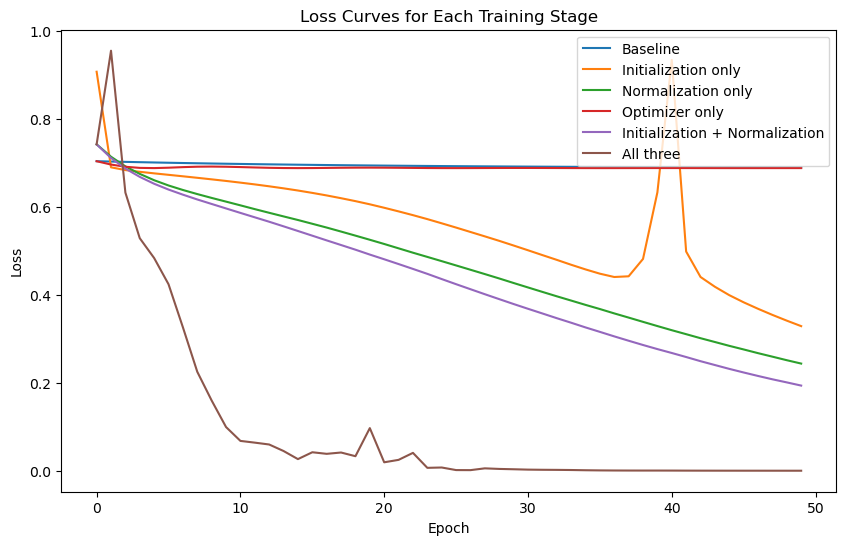

In [54]:
import matplotlib.pyplot as plt

epochs = range(50)

plt.figure(figsize=(10, 6))

plt.plot(epochs, base_losses, label="Baseline")
plt.plot(epochs, init_losses, label="Initialization only")
plt.plot(epochs, norm_losses, label="Normalization only")
plt.plot(epochs, opt_losses, label="Optimizer only")
plt.plot(epochs, init_norm_losses, label="Initialization + Normalization")
plt.plot(epochs, final_losses, label="All three")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves for Each Training Stage")
plt.legend()